# Реализация PPO, PPO + World Model в непрерывном пространстве

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
import imageio
from torch.distributions import Independent, Normal

from IPython.display import Image as IPyImage
from IPython.display import display, Image

## Гиперпараметры

In [ ]:
HP = {
    # Архитектура сети
    'hidden_size': 256,
    'activation': nn.Tanh,
    
    # Обучение агента
    'seeds': [42, 69],
    'max_episodes': 1000,
    'lr_policy': 1e-4,# стабильные
    'lr_wm': 3e-5,# стабильные


    'lr_policy': 1e-4,  # Было 3e-4
    'lr_wm': 3e-4,      # Было 1e-4

    
    # 'lr_policy': 3e-4,
    # 'lr_wm': 1e-4,
    'batch_size': 2048,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_eps': 0.2,
    'ent_coef': 0.001,
    'n_epochs': 5,
    
    # Модель мира
    # 'wm_train_steps': 5,
    'wm_train_steps': 15,
    'wm_batch_size': 512,
    'imagination_start': 200, # стабильные
    # 'imagination_start': 20,  # Эпизоды до включения WM
    
    # Нормализация
    'norm_eps': 1e-8,
    # 'grad_clip': 1.0, # Стабильные
    'grad_clip': 0.5,
    
    # Визуализация
    'plot_interval': 50,
    'gif_fps': 15,
    'render_frames': 300,
    'smooth_window': 50
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Вспомогательные классы и функции

In [ ]:
class RunningMeanStd:
    def __init__(self, shape):
        self.n = 0
        self.mean = np.zeros(shape)
        self.var = np.ones(shape)
    
    def update(self, x):
        x = np.asarray(x)
        if np.isnan(x).any() or np.isinf(x).any(): return
        m = np.nanmean(x, axis=0)
        v = np.nanvar(x, axis=0)
        count = x.shape[0]
        delta = m - self.mean
        new_mean = self.mean + delta * count / (self.n + count)
        m_a = self.var * self.n
        m_b = v * count
        M2 = m_a + m_b + delta**2 * self.n * count / (self.n + count)
        self.mean = new_mean
        self.var = M2 / (self.n + count)
        self.n += count

    def normalize(self, x):
        return (x - self.mean) / np.sqrt(self.var + HP['norm_eps'])

class SafeContinuousPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        # Общая сеть
        self.net = nn.Sequential(
            nn.Linear(obs_dim, HP['hidden_size']),
            HP['activation'](),
            nn.LayerNorm(HP['hidden_size']),
            nn.Linear(HP['hidden_size'], HP['hidden_size']),
            HP['activation'](),
            nn.LayerNorm(HP['hidden_size']),
        )
        # Выходы для actor
        self.mu = nn.Linear(HP['hidden_size'], act_dim)
        self.log_std_layer = nn.Linear(HP['hidden_size'], act_dim)
        # Критик
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, HP['hidden_size']),
            HP['activation'](),
            nn.LayerNorm(HP['hidden_size']),
            nn.Linear(HP['hidden_size'], HP['hidden_size']),
            HP['activation'](),
            nn.LayerNorm(HP['hidden_size']),
            nn.Linear(HP['hidden_size'], 1)
        )
        # Инициализация
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2)); nn.init.constant_(layer.bias, 0)
        nn.init.orthogonal_(self.mu.weight, gain=0.01); nn.init.constant_(self.mu.bias, 0)
        nn.init.orthogonal_(self.log_std_layer.weight, gain=0.01); nn.init.constant_(self.log_std_layer.bias, -3)
        for layer in self.critic:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2)); nn.init.constant_(layer.bias, 0)

    def forward(self, x):
        x = torch.clamp(x, -10, 10)
        feats = self.net(x)
        mu = torch.tanh(self.mu(feats)) * 2.0
        log_std = self.log_std_layer(feats)
        std = torch.exp(log_std).clamp(1e-3, 1.0)
        mu = torch.nan_to_num(mu, nan=0.0)
        std = torch.nan_to_num(std, nan=0.1)
        value = self.critic(x).squeeze(-1)
        return mu, std, value

class RobustWorldModel(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim+act_dim, HP['hidden_size']),
            HP['activation'](),
            nn.LayerNorm(HP['hidden_size']),
            nn.Linear(HP['hidden_size'], HP['hidden_size']),
            HP['activation'](),
            nn.LayerNorm(HP['hidden_size']),
        )
        self.next_state = nn.Linear(HP['hidden_size'], obs_dim)
        self.reward = nn.Linear(HP['hidden_size'], 1)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.constant_(layer.bias, 0)
        nn.init.orthogonal_(self.next_state.weight, gain=0.01)
        nn.init.constant_(self.next_state.bias, 0)
        nn.init.orthogonal_(self.reward.weight, gain=0.01)
        nn.init.constant_(self.reward.bias, 0)

    def forward(self, s, a):
        # Обработка входных данных
        s = torch.clamp(s, -10, 10)
        a = torch.clamp(a, -2, 2)
        
        # Конкатенация состояния и действия
        x = torch.cat([s, a], dim=-1)
        
        # Прямой проход через сеть
        h = self.net(x)
        h = torch.nan_to_num(h)
        
        # Предсказание следующего состояния и награды
        ns = self.next_state(h)
        r = torch.tanh(self.reward(h)) * 5.0  # Масштабирование выхода
        
        # Дополнительная защита от NaN/Inf
        ns = torch.nan_to_num(ns, nan=0.0)
        r = torch.nan_to_num(r, nan=0.0)
        
        return ns, r.squeeze(-1)

## PPO (GAE + Update)

In [ ]:
def safe_compute_gae(values, rewards, dones):
    adv = []; last_adv=0; next_v=0
    for t in reversed(range(len(rewards))):
        r = 0 if torch.isnan(rewards[t]) else rewards[t]
        delta = r + HP['gamma']*next_v*(1-dones[t]) - values[t]
        last_adv = delta + HP['gamma']*HP['gae_lambda']*(1-dones[t])*last_adv
        adv.insert(0, last_adv); next_v = values[t]
    adv = torch.nan_to_num(torch.tensor(adv, device=values.device))
    ret = torch.clamp(adv + values, -100, 100)
    return adv, ret

def stable_ppo_update(policy, optimizer, states, actions, old_log_probs, values, advs, returns):
    for _ in range(HP['n_epochs']):
        mu, std, vals = policy(states)

        # Проверка на NaN перед созданием распределения
        if torch.isnan(mu).any() or torch.isnan(std).any():
            print("NaN detected in policy outputs. Skipping epoch.")
            break
        
        dist = Independent(Normal(mu, std), 1)
        logp = dist.log_prob(actions)
        ratio = torch.exp(logp - old_log_probs)
        clipped = torch.clamp(ratio, 1-HP['clip_eps'], 1+HP['clip_eps'])
        advs = torch.clamp(advs, -5, 5)
        loss_pi = -torch.min(ratio*advs, clipped*advs).mean()
        loss_v = 0.5*torch.clamp((vals-returns).pow(2).mean(), max=100)
        loss_e = -HP['ent_coef']*torch.clamp(dist.entropy().mean(), min=-1, max=1)
        loss = loss_pi + loss_v + loss_e
        if torch.isnan(loss): break
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), HP['grad_clip'])
        optimizer.step()

## Тренировка агента

In [ ]:
def train(env_name, seed=42, use_wm=False, save_gif=False):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    env = gym.make(env_name, render_mode='rgb_array')
    obs_dim = env.observation_space.shape[0]; act_dim = env.action_space.shape[0]

    obs_norm = RunningMeanStd(obs_dim)
    rew_norm = RunningMeanStd(1)

    policy = SafeContinuousPolicy(obs_dim, act_dim).to(device)
    opt = optim.Adam(policy.parameters(), lr=HP['lr_policy'], eps=1e-5)
    wm, wm_opt = (None, None)
    if use_wm:
        wm = RobustWorldModel(obs_dim, act_dim).to(device)
        wm_opt = optim.Adam(wm.parameters(), lr=HP['lr_wm'], eps=1e-5)

    rewards = []
    steps = 0

    for ep in range(HP['max_episodes']):
        # Буферы
        real_buf = {'s':[], 'a':[], 'r':[], 'd':[], 'v':[], 'lp':[]}
        imag_buf = {'s':[], 'a':[], 'r':[], 'd':[], 'v':[], 'lp':[]}
        state, _ = env.reset(seed=seed+ep)
        ep_reward = 0; done = False

        # Собираем реальные траектории
        while len(real_buf['r']) < HP['batch_size'] and not done:
            s_n = obs_norm.normalize(state)
            # Проверка на валидность состояния
            if np.isnan(s_n).any() or np.isinf(s_n).any():
                done = True
                state, _ = env.reset()
                continue
            
            st = torch.FloatTensor(s_n).to(device).unsqueeze(0)
            with torch.no_grad(): mu, std, v = policy(st)
            dist = Independent(Normal(mu,std),1)
            a = dist.sample().clamp(-1,1)
            lp = dist.log_prob(a)
            a_np = a.cpu().numpy().squeeze()
        
            ns, r, term, trunc, _ = env.step(a_np)
            done = term or trunc
            
            # Проверка нового состояния на NaN/Inf
            if np.isnan(ns).any() or np.isinf(ns).any():
                done = True
                ns, _ = env.reset()
                r = 0
            
            r = np.nan_to_num(r, 0)
            rn = rew_norm.normalize(r).item()
        
            real_buf['s'].append(s_n)
            real_buf['a'].append(a_np)
            real_buf['r'].append(rn)
            real_buf['d'].append(done)
            real_buf['v'].append(v.item())
            real_buf['lp'].append(lp.item())
        
            state = ns
            ep_reward += r
            steps +=1
            obs_norm.update([ns])
            rew_norm.update([[r]])

        if use_wm and ep >= HP['imagination_start']:
            imag_state = obs_norm.normalize(state)
            while len(imag_buf['r']) < HP['batch_size']:
                st = torch.FloatTensor(imag_state).to(device).unsqueeze(0)
                with torch.no_grad():
                    mu, std, v_i = policy(st)
                    dist = Independent(Normal(mu, std), 1)
                    a_i = dist.sample().clamp(-1, 1)
                    lp_i = dist.log_prob(a_i)
                    ns_pred, r_pred = wm(st, a_i)
                    
                    # Проверка предсказаний WM
                    if torch.isnan(ns_pred).any() or torch.isinf(ns_pred).any():
                        imag_state = obs_norm.normalize(env.reset()[0])
                        continue
                        
                ns_np = ns_pred.squeeze(0).cpu().numpy()
                if np.isnan(ns_np).any() or np.isinf(ns_np).any():
                    imag_state = obs_norm.normalize(env.reset()[0])
                    continue

                rn_i = rew_norm.normalize(r_pred.item()).item()
        
                imag_buf['s'].append(imag_state)
                imag_buf['a'].append(a_i.cpu().numpy().squeeze())
                imag_buf['r'].append(rn_i)
                imag_buf['d'].append(False)
                imag_buf['v'].append(v_i.item())
                imag_buf['lp'].append(lp_i.item())
        
                imag_state = obs_norm.normalize(ns_np)
                if len(imag_buf['r']) >= HP['batch_size']:
                    break

            # Обучение WM на реальных данных с проверкой
            if use_wm and len(real_buf['r']) > 0:
                batch_size = min(HP['wm_batch_size'], len(real_buf['r']))
                replace = batch_size > len(real_buf['r'])
                data_idx = np.random.choice(len(real_buf['r']), batch_size, replace=replace)
                
                s_b = torch.FloatTensor(np.array(real_buf['s'])[data_idx]).to(device)
                a_b = torch.FloatTensor(np.array(real_buf['a'])[data_idx]).to(device)

                # Пропуск батчей с NaN
                if torch.isnan(s_b).any() or torch.isnan(a_b).any():
                    continue

                ns_true = torch.FloatTensor(np.array(real_buf['s'])[data_idx]+0).to(device)
                rs_true = torch.FloatTensor(np.array(real_buf['r'])[data_idx]).to(device)
                
                for _ in range(HP['wm_train_steps']):
                    ns_pred, r_pred = wm(s_b, a_b)
                    loss = nn.MSELoss()(ns_pred, ns_true) + nn.MSELoss()(r_pred, rs_true)
                    wm_opt.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(wm.parameters(), HP['grad_clip'])
                    wm_opt.step()

        # Комбинируем буферы для PPO
        if use_wm and imag_buf['r']:
            buf = {k: real_buf[k]+imag_buf[k] for k in real_buf}
        else:
            buf = real_buf

        # Тензоры
        st = torch.FloatTensor(np.array(buf['s'])).to(device)
        at = torch.FloatTensor(np.array(buf['a'])).to(device)
        lp = torch.FloatTensor(np.array(buf['lp'])).to(device)
        vw = torch.FloatTensor(np.array(buf['v'])).to(device)
        dr = torch.FloatTensor(np.array(buf['d'],dtype=float)).to(device)
        rr = torch.FloatTensor(np.array(buf['r'])).to(device)

        adv, ret = safe_compute_gae(vw, rr, dr)
        stable_ppo_update(policy, opt, st, at, lp, vw, adv, ret)

        rewards.append(ep_reward)
        if ep % HP['plot_interval'] == 0:
            avg = np.mean(rewards[-HP['plot_interval']:])
            print(f"Ep {ep}| Reward {ep_reward:.1f}| Avg {avg:.1f}| Steps {steps}")

    # GIF
    if save_gif:
        frames=[]
        state,_=env.reset(seed=seed)
        for _ in range(HP['render_frames']):
            img = env.render()
            frames.append(img)
            s_n = obs_norm.normalize(state)
            st = torch.FloatTensor(s_n).to(device).unsqueeze(0)
            with torch.no_grad(): mu,_,_=policy(st)
            act = mu.clamp(-1,1).cpu().numpy().squeeze()
            state, _, done, _, _ = env.step(act)
            if done: break
        typ = 'wm' if use_wm else 'ppo'
        imageio.mimsave(f'bipedal_{typ}_seed{seed}.gif', frames, fps=HP['gif_fps'])

    env.close()
    return rewards, policy, obs_norm, rew_norm

## Запуск экспериментов

In [1]:
policies = []
results = {'ppo':[], 'wm':[]}

for seed in HP['seeds']:
    # Обучаем PPO
    print(f'Training PPO seed {seed}')
    r_ppo, p_ppo, obs_norm_ppo, _ = train('BipedalWalker-v3', seed, use_wm=False)
    results['ppo'].append(r_ppo)
    
    # Обучаем PPO+WM
    print(f'Training PPO+WM seed {seed}')
    r_wm, p_wm, obs_norm_wm, _ = train('BipedalWalker-v3', seed, use_wm=True)
    results['wm'].append(r_wm)
    
    # Сохраняем политики и нормализаторы
    policies.append( (p_ppo, p_wm, obs_norm_ppo, obs_norm_wm) )

Training PPO seed 42
Ep 0| Reward -94.2| Avg -94.2| Steps 91
Ep 50| Reward -111.8| Avg -97.2| Steps 14945
Ep 100| Reward -99.8| Avg -95.6| Steps 31192
Ep 150| Reward -124.5| Avg -56.3| Steps 79315
Ep 200| Reward -121.0| Avg -74.3| Steps 120938
Ep 250| Reward -95.3| Avg -99.8| Steps 125341
Ep 300| Reward -25.0| Avg -91.9| Steps 146029
Ep 350| Reward -45.5| Avg -56.7| Steps 212875
Ep 400| Reward -127.9| Avg -56.0| Steps 279854
Ep 450| Reward -120.2| Avg -67.3| Steps 334613
Ep 500| Reward -54.5| Avg -51.7| Steps 405483
Ep 550| Reward -42.4| Avg -47.6| Steps 476443
Ep 600| Reward -44.4| Avg -41.4| Steps 556443
Ep 650| Reward -28.9| Avg -48.0| Steps 630376
Ep 700| Reward -117.2| Avg -93.8| Steps 641606
Ep 750| Reward -117.7| Avg -100.1| Steps 648772
Ep 800| Reward -93.1| Avg -93.2| Steps 660259
Ep 850| Reward -120.8| Avg -95.9| Steps 668682
Ep 900| Reward -94.1| Avg -96.8| Steps 674107
Ep 950| Reward -119.3| Avg -101.5| Steps 679862
Training PPO+WM seed 42
Ep 0| Reward -94.2| Avg -94.2| Ste

## Визуализация

Генерация графиков...


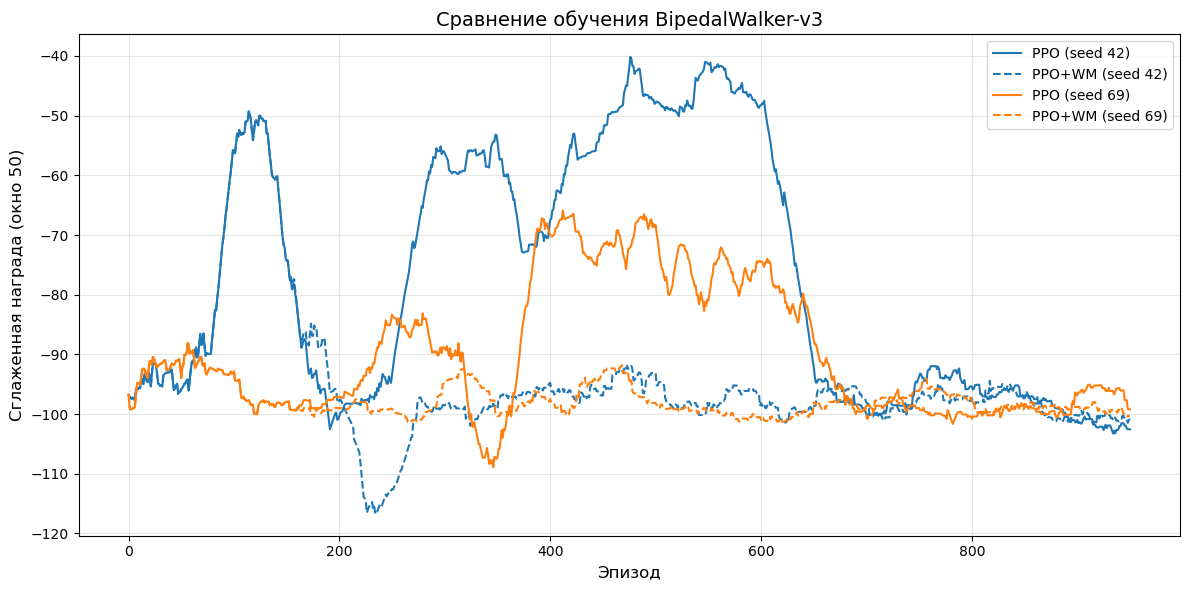

In [4]:
def plot_results(rets_ppo, rets_wm, seeds):
    plt.figure(figsize=(12, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    smooth = lambda x: np.convolve(np.nan_to_num(x), 
                                 np.ones(HP['smooth_window'])/HP['smooth_window'], 
                                 mode='valid')
    
    for i, (r_ppo, r_wm) in enumerate(zip(rets_ppo, rets_wm)):
        plt.plot(smooth(r_ppo), color=colors[i], linestyle='-', label=f"PPO (seed {seeds[i]})")
        plt.plot(smooth(r_wm), color=colors[i], linestyle='--', label=f"PPO+WM (seed {seeds[i]})")
    
    plt.title("Сравнение обучения BipedalWalker-v3", fontsize=14)
    plt.xlabel("Эпизод", fontsize=12)
    plt.ylabel(f"Сглаженная награда (окно {HP['smooth_window']})", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Генерация графиков...')
plot_results(results['ppo'], results['wm'], HP['seeds'])

## Генератор GIF для всех политик

Генерация GIF...
walker_ppo_seed42.gif


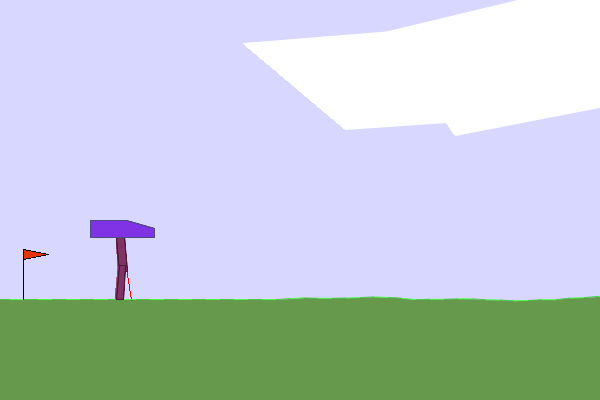

walker_wm_seed42.gif


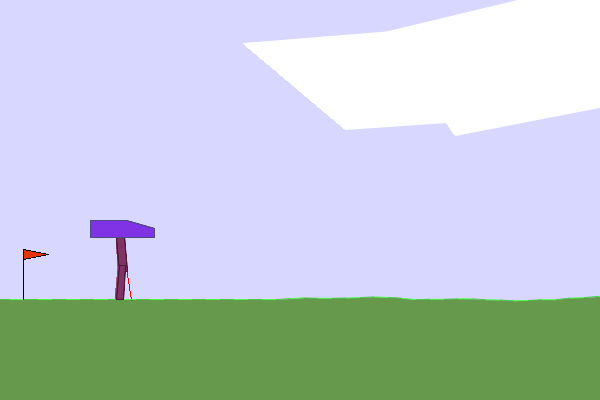

walker_ppo_seed69.gif


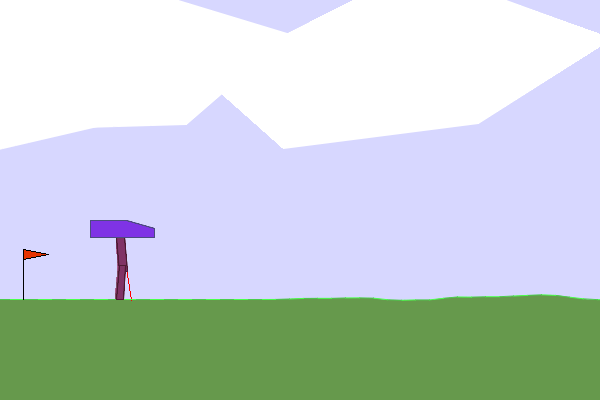

walker_wm_seed69.gif


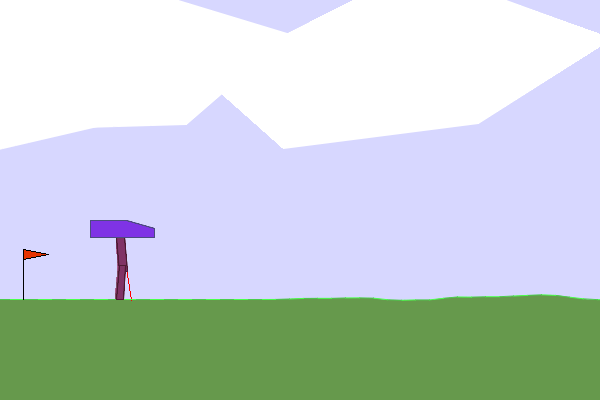

In [5]:
def render_policy(env_name, policy, obs_norm, seed, filename):
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset(seed=seed)
    frames = []
    
    for _ in range(HP['render_frames']):
        img = env.render()
        frames.append(img)
        s_n = obs_norm.normalize(state)
        st = torch.FloatTensor(s_n).to(device).unsqueeze(0)
        with torch.no_grad():
            mu, _, _ = policy(st)
        act = mu.clamp(-1, 1).cpu().numpy().squeeze()
        state, _, done, _, _ = env.step(act)
        if done: break
    
    imageio.mimsave(filename, frames, fps=HP['gif_fps'])
    env.close()


def generate_gifs(policies, seeds):
    for (ppo_pol, wm_pol, obs_norm_ppo, obs_norm_wm), seed in zip(policies, seeds):
        # Рендерим PPO
        render_policy(
            'BipedalWalker-v3', 
            ppo_pol, 
            obs_norm_ppo,
            seed, 
            f'walker_ppo_seed{seed}.gif'
        )
        print(f'walker_ppo_seed{seed}.gif')
        display(Image(filename=f'walker_ppo_seed{seed}.gif', format='gif'))
        
        # Рендерим PPO+WM
        if wm_pol is not None:
            render_policy(
                'BipedalWalker-v3', 
                wm_pol,
                obs_norm_wm,
                seed,
                f'walker_wm_seed{seed}.gif'
            )
            print(f'walker_wm_seed{seed}.gif')
            display(Image(filename=f'walker_wm_seed{seed}.gif', format='gif'))

print('Генерация GIF...')
generate_gifs(policies, HP['seeds'])


## Выводы

### World Model не улучшил PPO

- При обучении в течение 1000 шагов World Model продемонстрировала высокую стабильность и стойкость убеждений

### Ключевые гиперпараметры:

- lr_policy=1e-4 и lr_wm=3e-4 — получилось найти хороший баланс.
- wm_train_steps=15 — достаточно для модели модели.